# Optimal transport based dataset similarity

**Background reading:**

* Geometric Dataset Distances via Optimal Transport: https://proceedings.neurips.cc/paper/2020/file/f52a7b2610fb4d3f74b4106fb80b233d-Paper.pdf
* OTT-JAX: https://github.com/ott-jax/ott

**Methods background:**

* The method is based on computing a optimal transport mapping between the query in the reference dataset
* The cell to cell transport cost is split into two parts:
  1. Distance in gene expression space
      * Measured via Spearman correlation between the two gene expression vectors $x_{i}$ and $x_j$
      * $distance_{gene-expression} = SpearmanR(x_{i}, x_j)$
  2. Distance between cell-type clusters
      * Measured as the overlap of differentially expressed genes (DE genes) between the two associated cell-type clusters $celltype_i$ and $celltype_j$
      * The overlap is measured by the Jaccard distance: https://en.wikipedia.org/wiki/Jaccard_index
      * The DE genes are calcuated per dataset and use all of the other clusters as the reference (one-vs-rest).
* The overall distance is then calculated as: $distance_{cell-cell} = distance_{gene-expression} + distance_{cluster}$
* The resulting transport map is then aggrgated per cell-type cluster:
  * Transport map aggregation
    * This shows where the mass of each cell-type cluster in the query dataset gets mapped to in the reference dataset.
  * Transport cost between clusters
    * This shows how similar the mapped cell-type clusters are.
    * The transport cost is between $0.$ and $2.$ &rarr; $0.$ corresponds to a perfect overlap, and $2.$ corresponds to completly different clusters.
* The method uses unbalanced optimal transport to account for if not all cell-types from the query data are observed in the reference data.
  * The imbalanced parameters `tau_a` and `tau_b` should be adjusted accordingly, depending on how much the cell-types overlap between the query and reference dataset.
  * The parameters can be set in the init_problem call: `dataset_map.init_problem(tau_a=0.75, tau_b=0.75)`


In [1]:
%env LA_PYTHON_CLIENT_MEM_FRACTION=.99

env: LA_PYTHON_CLIENT_MEM_FRACTION=.99


In [2]:
%load_ext autoreload

In [3]:
import warnings
from os.path import join

import scanpy as sc

In [4]:
%autoreload
from datasim.dataset_ot import DatasetMapping

## Load data

In [5]:
DATA_PATH = "/vol/data/dataset-similarity"

# load and preprocess data
adata_query, adata_ref = DatasetMapping.preprocess_adatas(
    sc.read_h5ad(join(DATA_PATH, "01ad3cd7-3929-4654-84c0-6db05bd5fd59_processed.h5ad")),
    sc.read_h5ad(join(DATA_PATH, "b0e547f0-462b-4f81-b31b-5b0a5d96f537_processed.h5ad")),
    n_top_genes=1000
)

/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:508: FutureWarning: The provided callable <function nanmean at 0x7f90

In [6]:
# sc.pp.subsample(adata_query, fraction=0.75)
# sc.pp.subsample(adata_ref, fraction=0.75)

In [7]:
adata_query

AnnData object with n_obs × n_vars = 600929 × 1000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author'
    var: 'gene_names'
    uns: 'log1p'

In [8]:
adata_ref

AnnData object with n_obs × n_vars = 1058909 × 1000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author'
    var: 'gene_names'
    uns: 'log1p'

## Intialize and fit optimal transport model

In [9]:
dataset_map = DatasetMapping(adata_query, adata_ref)

In [10]:
# ignore warnings here as scanpy.tl.rank_genes_groups throws a lot of warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dataset_map.init_geom(batch_size=1024, epsilon=0.05)

In [11]:
print(f"x size: {dataset_map.geom.x.shape[0] * dataset_map.geom.x.shape[1] * 4 / 1000**3} GB")
print(f"y size: {dataset_map.geom.y.shape[0] * dataset_map.geom.y.shape[1] * 4 / 1000**3} GB")

x size: 2.406119716 GB
y size: 4.239871636 GB


In [12]:
dataset_map.init_problem(tau_a=0.75, tau_b=0.75)

In [13]:
dataset_map.solve();

  1%|█▍                                                                                                                                                  | 2/200 [50:45<83:45:43, 1522.95s/it, error: 3.257882e-04]


## Visualize optimal transport mapping

In [28]:
%autoreload
from datasim.plotting import plot_cluster_mapping, plot_cluster_distance, plot_sankey

### Cluster mapping

In [15]:
cluster_mapping = dataset_map.compute_cluster_mapping(normalize=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [46:36<00:00, 69.91s/it]


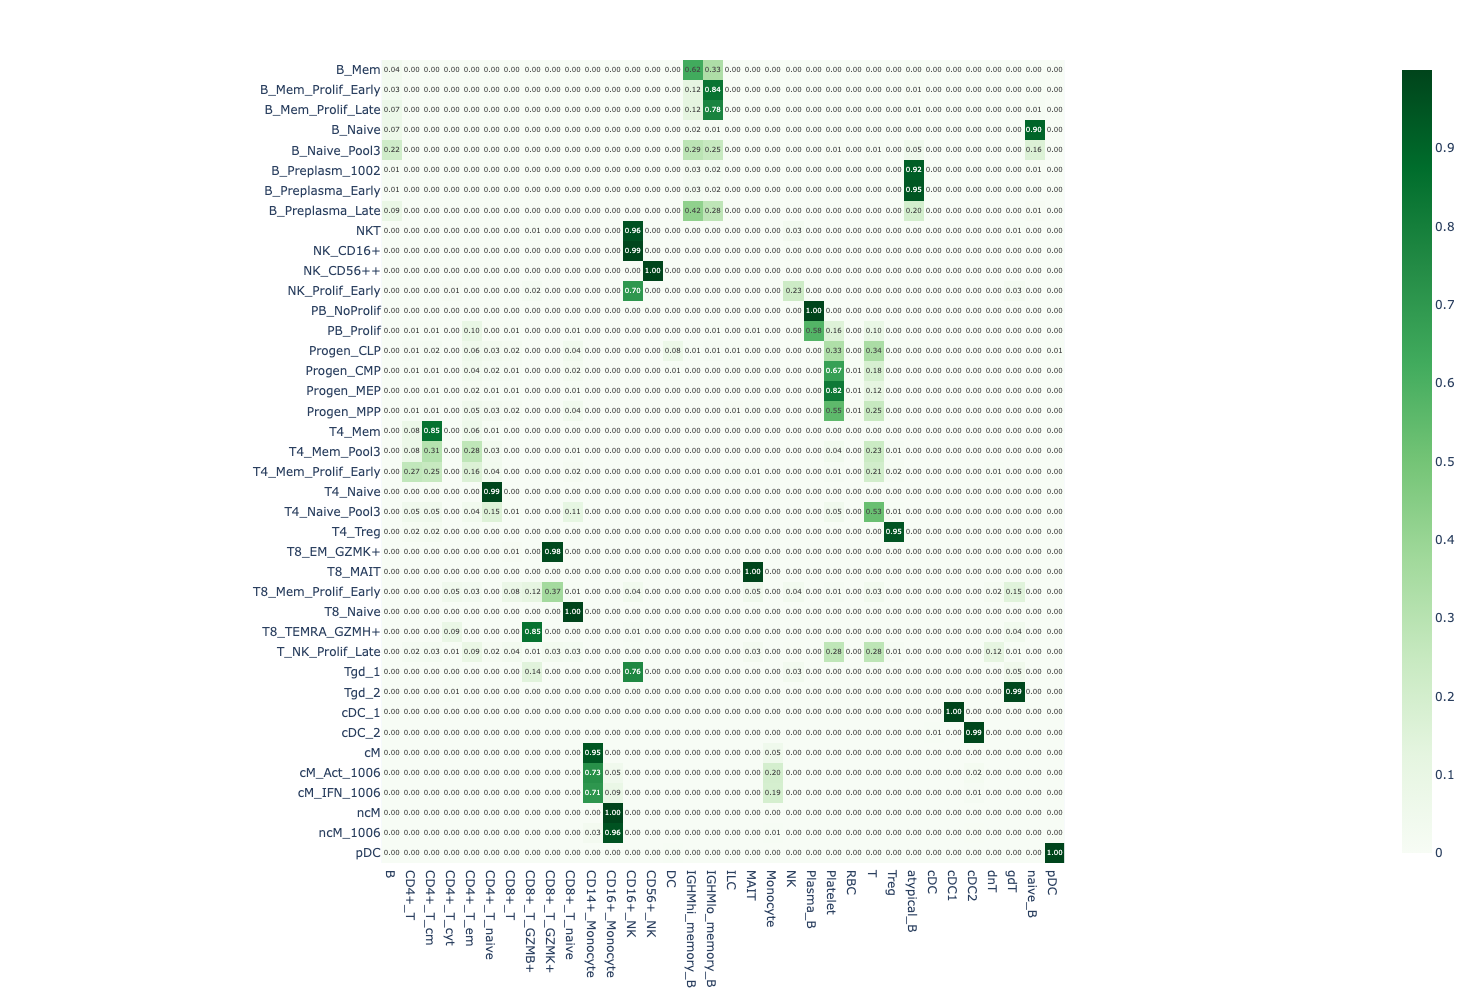

In [29]:
plot_cluster_mapping(cluster_mapping)

### Cluster distances

In [17]:
cluster_distance = dataset_map.compute_cluster_distances(n_samples=25000)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1360/1360 [15:44<00:00,  1.44it/s]


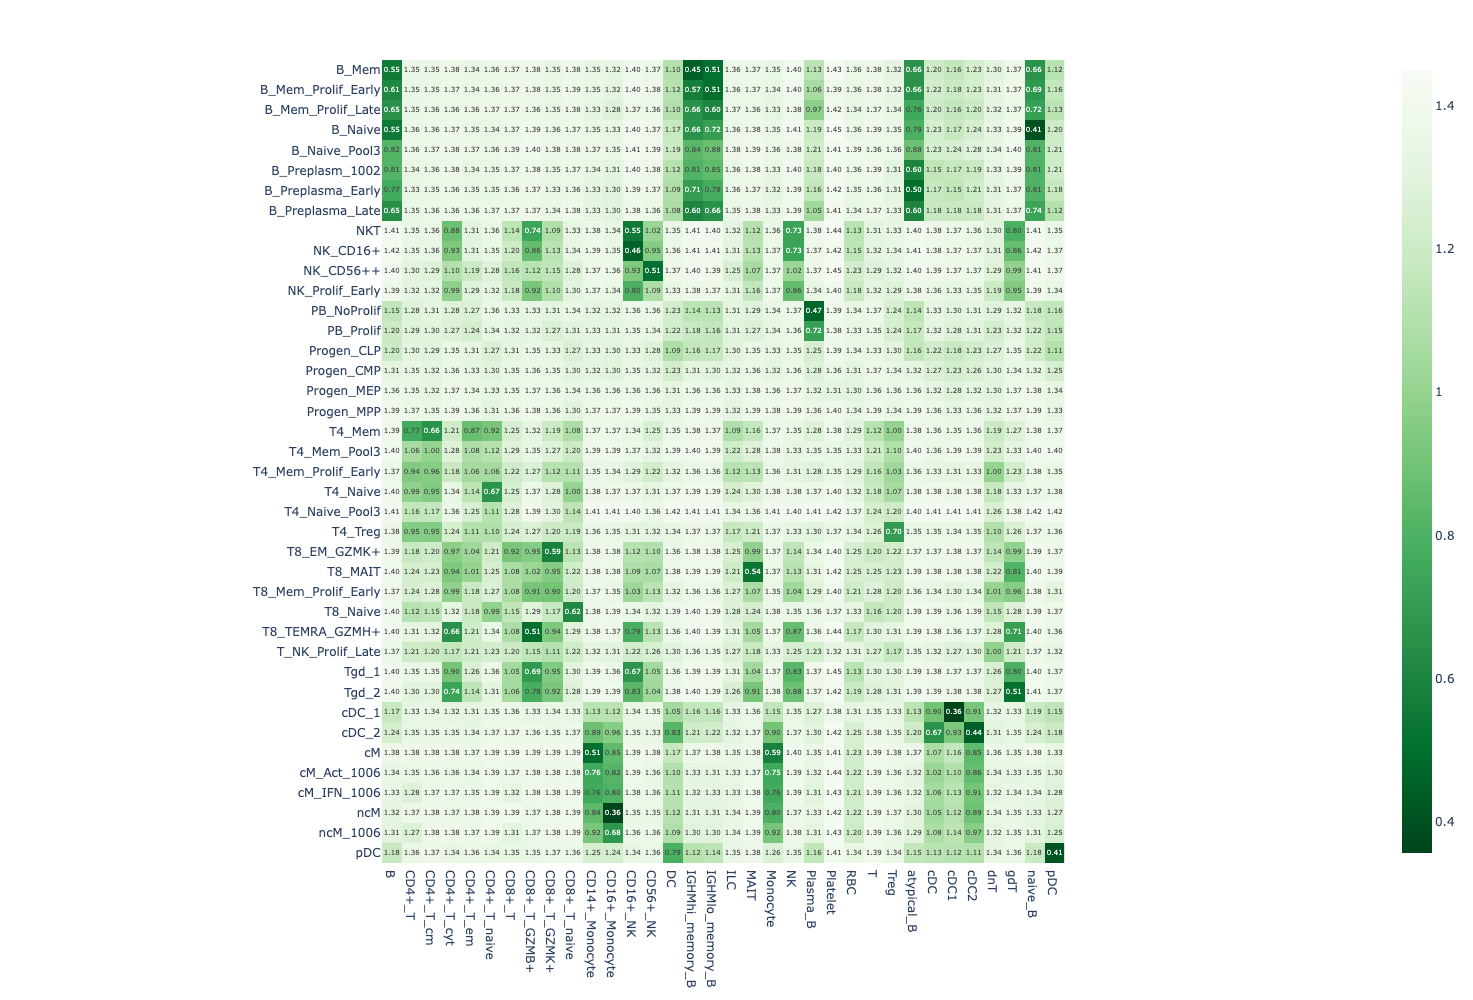

In [30]:
plot_cluster_distance(cluster_distance, show=True)

### Sankey visualization

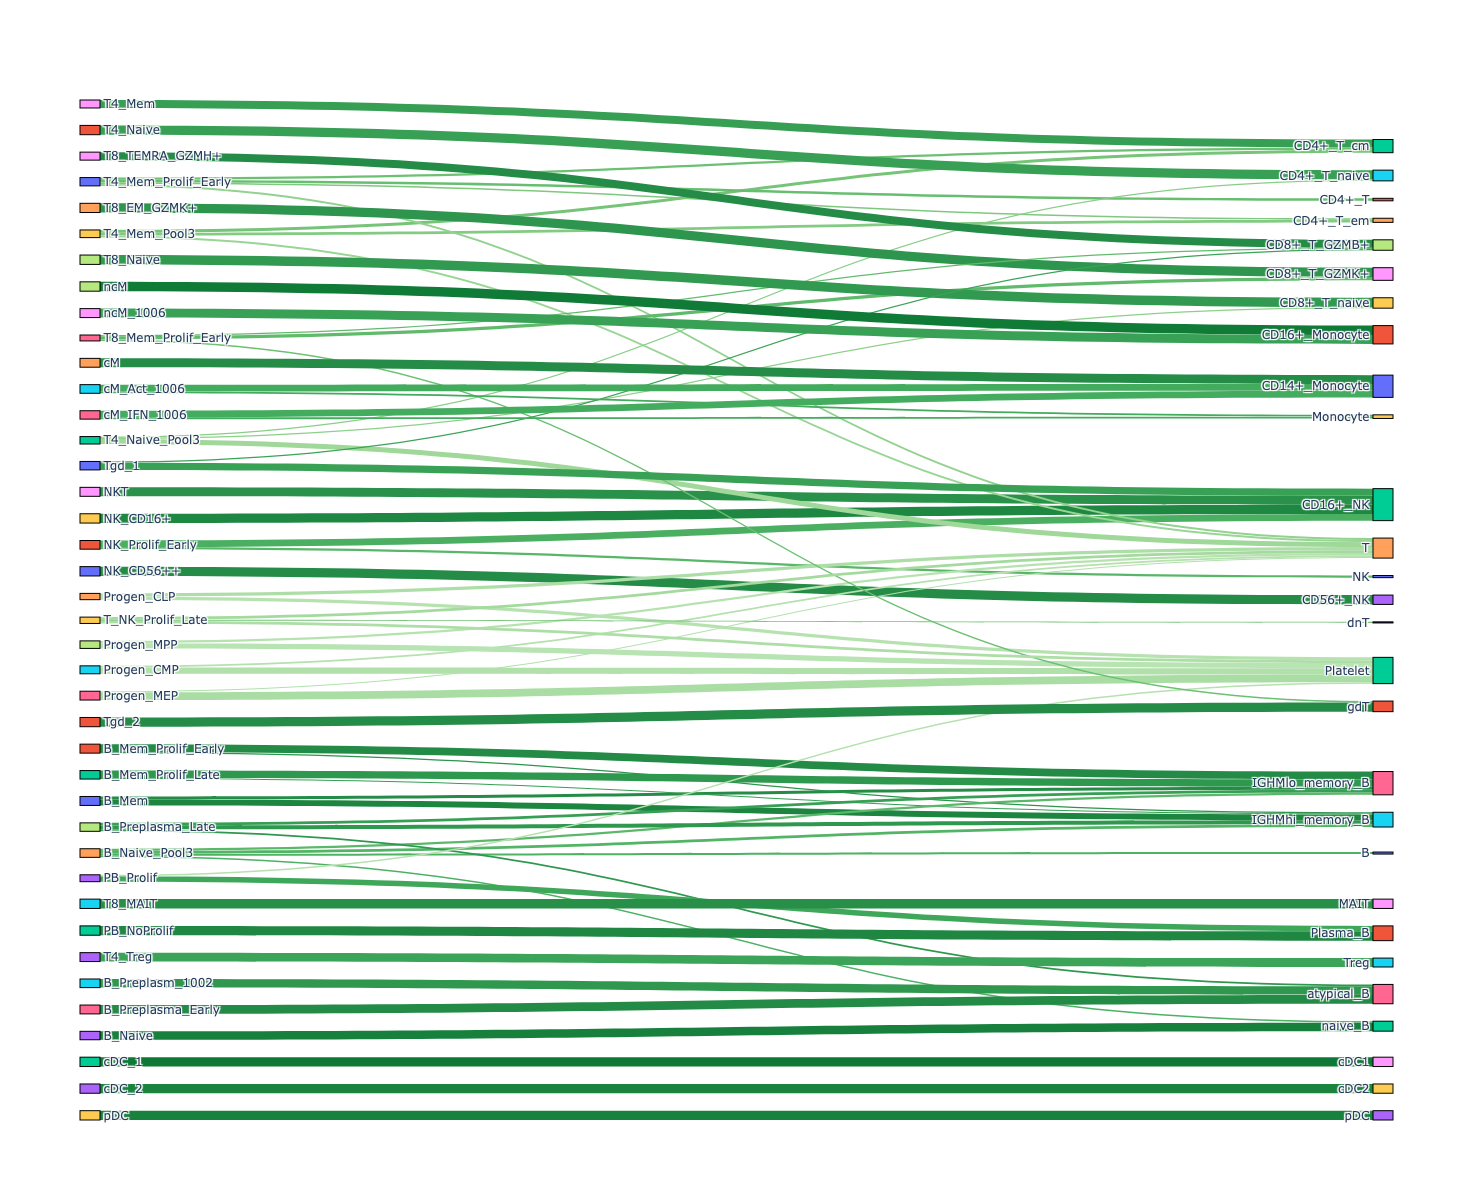

In [26]:
plot_sankey(cluster_mapping, cluster_distance)

### Top n most similar clusters

In [20]:
top_n_labels = DatasetMapping.select_most_similar_clusters(cluster_mapping, threshold=0.1, n_top=5)
top_n_labels

{'B_Mem': ['IGHMhi_memory_B', 'IGHMlo_memory_B'],
 'B_Mem_Prolif_Early': ['IGHMlo_memory_B', 'IGHMhi_memory_B'],
 'B_Mem_Prolif_Late': ['IGHMlo_memory_B', 'IGHMhi_memory_B'],
 'B_Naive': ['naive_B'],
 'B_Naive_Pool3': ['IGHMhi_memory_B', 'IGHMlo_memory_B', 'B', 'naive_B'],
 'B_Preplasm_1002': ['atypical_B'],
 'B_Preplasma_Early': ['atypical_B'],
 'B_Preplasma_Late': ['IGHMhi_memory_B', 'IGHMlo_memory_B', 'atypical_B'],
 'NKT': ['CD16+_NK'],
 'NK_CD16+': ['CD16+_NK'],
 'NK_CD56++': ['CD56+_NK'],
 'NK_Prolif_Early': ['CD16+_NK', 'NK'],
 'PB_NoProlif': ['Plasma_B'],
 'PB_Prolif': ['Plasma_B', 'Platelet'],
 'Progen_CLP': ['T', 'Platelet'],
 'Progen_CMP': ['Platelet', 'T'],
 'Progen_MEP': ['Platelet', 'T'],
 'Progen_MPP': ['Platelet', 'T'],
 'T4_Mem': ['CD4+_T_cm'],
 'T4_Mem_Pool3': ['CD4+_T_cm', 'CD4+_T_em', 'T'],
 'T4_Mem_Prolif_Early': ['CD4+_T', 'CD4+_T_cm', 'T', 'CD4+_T_em'],
 'T4_Naive': ['CD4+_T_naive'],
 'T4_Naive_Pool3': ['T', 'CD4+_T_naive', 'CD8+_T_naive'],
 'T4_Treg': ['Treg'],
